In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import cfgrib

import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation import metrics
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.training.finetuner import VAEFinetuner
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.evaluation.pca_kmeans import PCAKmeansTrainer,  PCAKmeansPredictor

import matplotlib.pyplot as plt
plt.style.use('default')



/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
I0000 00:00:1789642674.526926  563624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789642674.527593  563624 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789642674.571641  563624 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789642677.620327  563624 port.cc:153] oneDNN custom operations are on. You ma

In [3]:
%load_ext autoreload
%autoreload 2

## Parameters

In [55]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/CH/"
data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
cluster_number = 8
original_dim = 575
pr_cluster_number = 8
batch_size = 128
epochs = 500

## Data loading and pre-processing

In [56]:
#create clusters for country-wise energy data
path = data_path + "WON_country_wise.csv"

df_in = pd.read_csv(path, comment="#")

df_filtered = df_in.copy()
df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

df_countries = df_filtered.drop(columns=["Date"])
df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)
df_countries = df_countries[["CH"]]

df_target, df_target_clusters = utils.calc_quantiles_UK(df_countries, cluster_number=pr_cluster_number, standardize=True)

#df_target_clusters.to_csv(data_path + "WON_clusters_norm.csv")
#df_target.to_csv(data_path + "WON_country_wise_norm.csv")
df_target_clusters.to_csv(data_path + "CH_8_clusters_norm.csv")
df_target.to_csv(data_path + "CH_country_wise_norm.csv")

#df_target_clusters = pd.read_csv(data_path + "WON_clusters_norm.csv", index_col=0)
#df_target = pd.read_csv(data_path + "WON_country_wise_norm.csv", index_col=0)

In [57]:
# Get training data
z500 = utils.preprocess_dataset(filename = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = utils.GeographicalFilter.EXTENDED_EUROPE,
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
std_dev = z500.std()
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)


# Get training data labels
target_labels = pd.read_csv(data_path + 'CH_8_clusters_norm.csv')
target_labels.columns = ['index', 'labels']

target_labels['values']=[1]*len(target_labels)
target_categorical_pd = pd.pivot_table(target_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
target_categorical = target_categorical_pd.values



In [58]:
#set training and testing data
training_indices = np.where(z500['time.year'] < 2015)[0]
testing_indices = np.where(z500['time.year'] >= 2015)[0]

z500_training = z500[training_indices]
z500_testing = z500[testing_indices]

z500_reshaped_training = z500_reshaped[training_indices]
z500_reshaped_testing = z500_reshaped[testing_indices]

target_categorical_training = target_categorical[training_indices]
target_categorical_testing = target_categorical[testing_indices]

df_target_training = df_target.iloc[training_indices]
df_target_testing = df_target.iloc[testing_indices]

In [59]:
print("count of each label", target_categorical_training.sum(axis=0)/target_categorical_training.sum())

count of each label [0.12796577 0.1201867  0.12427071 0.12465967 0.12504862 0.12640996
 0.12563205 0.12582653]


## Define model (single run)

In [60]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5 #1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500_training.values,
    y=target_categorical_training,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(results_path+'final_weights_UK_'+str(cluster_number)+'_4_5_training_test_500.weights.h5')

Epoch 1/500


KeyboardInterrupt: 

In [11]:
history.history.items()

dict_items([('cluster_target_regularisation_loss', [0.2176520824432373, 0.3576667308807373, 0.35547688603401184, 0.32320600748062134, 0.3345683813095093, 0.3309175372123718, 0.33239054679870605, 0.3303939402103424, 0.363839715719223, 0.3790573179721832, 0.40001818537712097, 0.41922304034233093, 0.4290669858455658, 0.4459705352783203, 0.46973124146461487, 0.4789344072341919, 0.4962989091873169, 0.5110528469085693, 0.5257903337478638, 0.5398083925247192, 0.549964964389801, 0.5583882927894592, 0.5602747201919556, 0.5669173002243042, 0.5848475694656372, 0.5827121734619141, 0.5936012268066406, 0.6093902587890625, 0.6098116040229797, 0.6166756749153137, 0.6262576580047607, 0.6301619410514832, 0.6280925869941711, 0.6304266452789307, 0.6330678462982178, 0.6468984484672546, 0.651210606098175, 0.6510310173034668, 0.6475028395652771, 0.65055912733078, 0.6504472494125366, 0.6568486094474792, 0.6525920033454895, 0.6532784104347229, 0.6582854390144348, 0.6594210863113403, 0.6545095443725586, 0.65730

## Plot training and validation losses

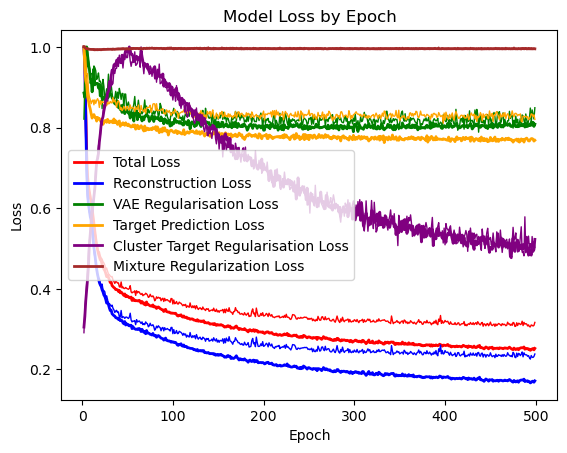

In [32]:
utils.plot_all_losses(loss_terms=history.history.items())

## Cross validation

In [61]:
vae = VAETrainer(cfg=config,  path_to_save_weights=results_path, loss_factors=loss_config)
vae.compile()

cross_validator = CrossValidator(vae=vae,filepath=results_path,cluster_number=cluster_number,n_runs=10)
histories = cross_validator.run(X=z500_training.values,y=target_categorical_training,epochs=epochs, batch_size=batch_size)

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - cluster_target_regularisation_loss: 0.2426 - mixture_regularization_loss: 8.8187 - reconstruction_loss: 502.5109 - target_prediction_loss: 18.7809 - total_loss: 540.1179 - vae_regularisation_loss: 9.7649 - val_cluster_target_regularisation_loss: 0.4026 - val_mixture_regularization_loss: 8.7396 - val_reconstruction_loss: 390.4331 - val_target_prediction_loss: 19.4641 - val_total_loss: 437.8665 - val_vae_regularisation_loss: 18.8270
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - cluster_target_regularisation_loss: 0.3522 - mixture_regularization_loss: 8.7123 - reconstruction_loss: 305.6963 - target_prediction_loss: 19.7756 - total_loss: 354.8339 - vae_regularisation_loss: 20.2976 - val_cluster_target_regularisation_loss: 0.3214 - val_mixture_regularization_loss: 8.6727 - val_reconstruction_loss: 248.6628 - val_target_prediction_loss: 19.9502 - val_total_loss: 298.1939 - val_vae_regularisation_loss: 20.5868
Epoch 3/500
29/29 ━━━

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - cluster_target_regularisation_loss: 0.2597 - mixture_regularization_loss: 8.7047 - reconstruction_loss: 518.7282 - target_prediction_loss: 19.1433 - total_loss: 556.9803 - vae_regularisation_loss: 10.1445 - val_cluster_target_regularisation_loss: 0.4134 - val_mixture_regularization_loss: 8.5231 - val_reconstruction_loss: 354.7833 - val_target_prediction_loss: 20.5995 - val_total_loss: 400.4407 - val_vae_regularisation_loss: 16.1214
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - cluster_target_regularisation_loss: 0.4586 - mixture_regularization_loss: 8.4410 - reconstruction_loss: 286.9710 - target_prediction_loss: 20.5087 - total_loss: 339.0034 - vae_regularisation_loss: 22.6240 - val_cluster_target_regularisation_loss: 0.5354 - val_mixture_regularization_loss: 8.3844 - val_reconstruction_loss: 245.8324 - val_target_prediction_loss: 19.3580 - val_total_loss: 295.6133 - val_vae_regularisation_loss: 21.5032
Epoch 3/500
29/29 ━━━━━━━━━━━━━━

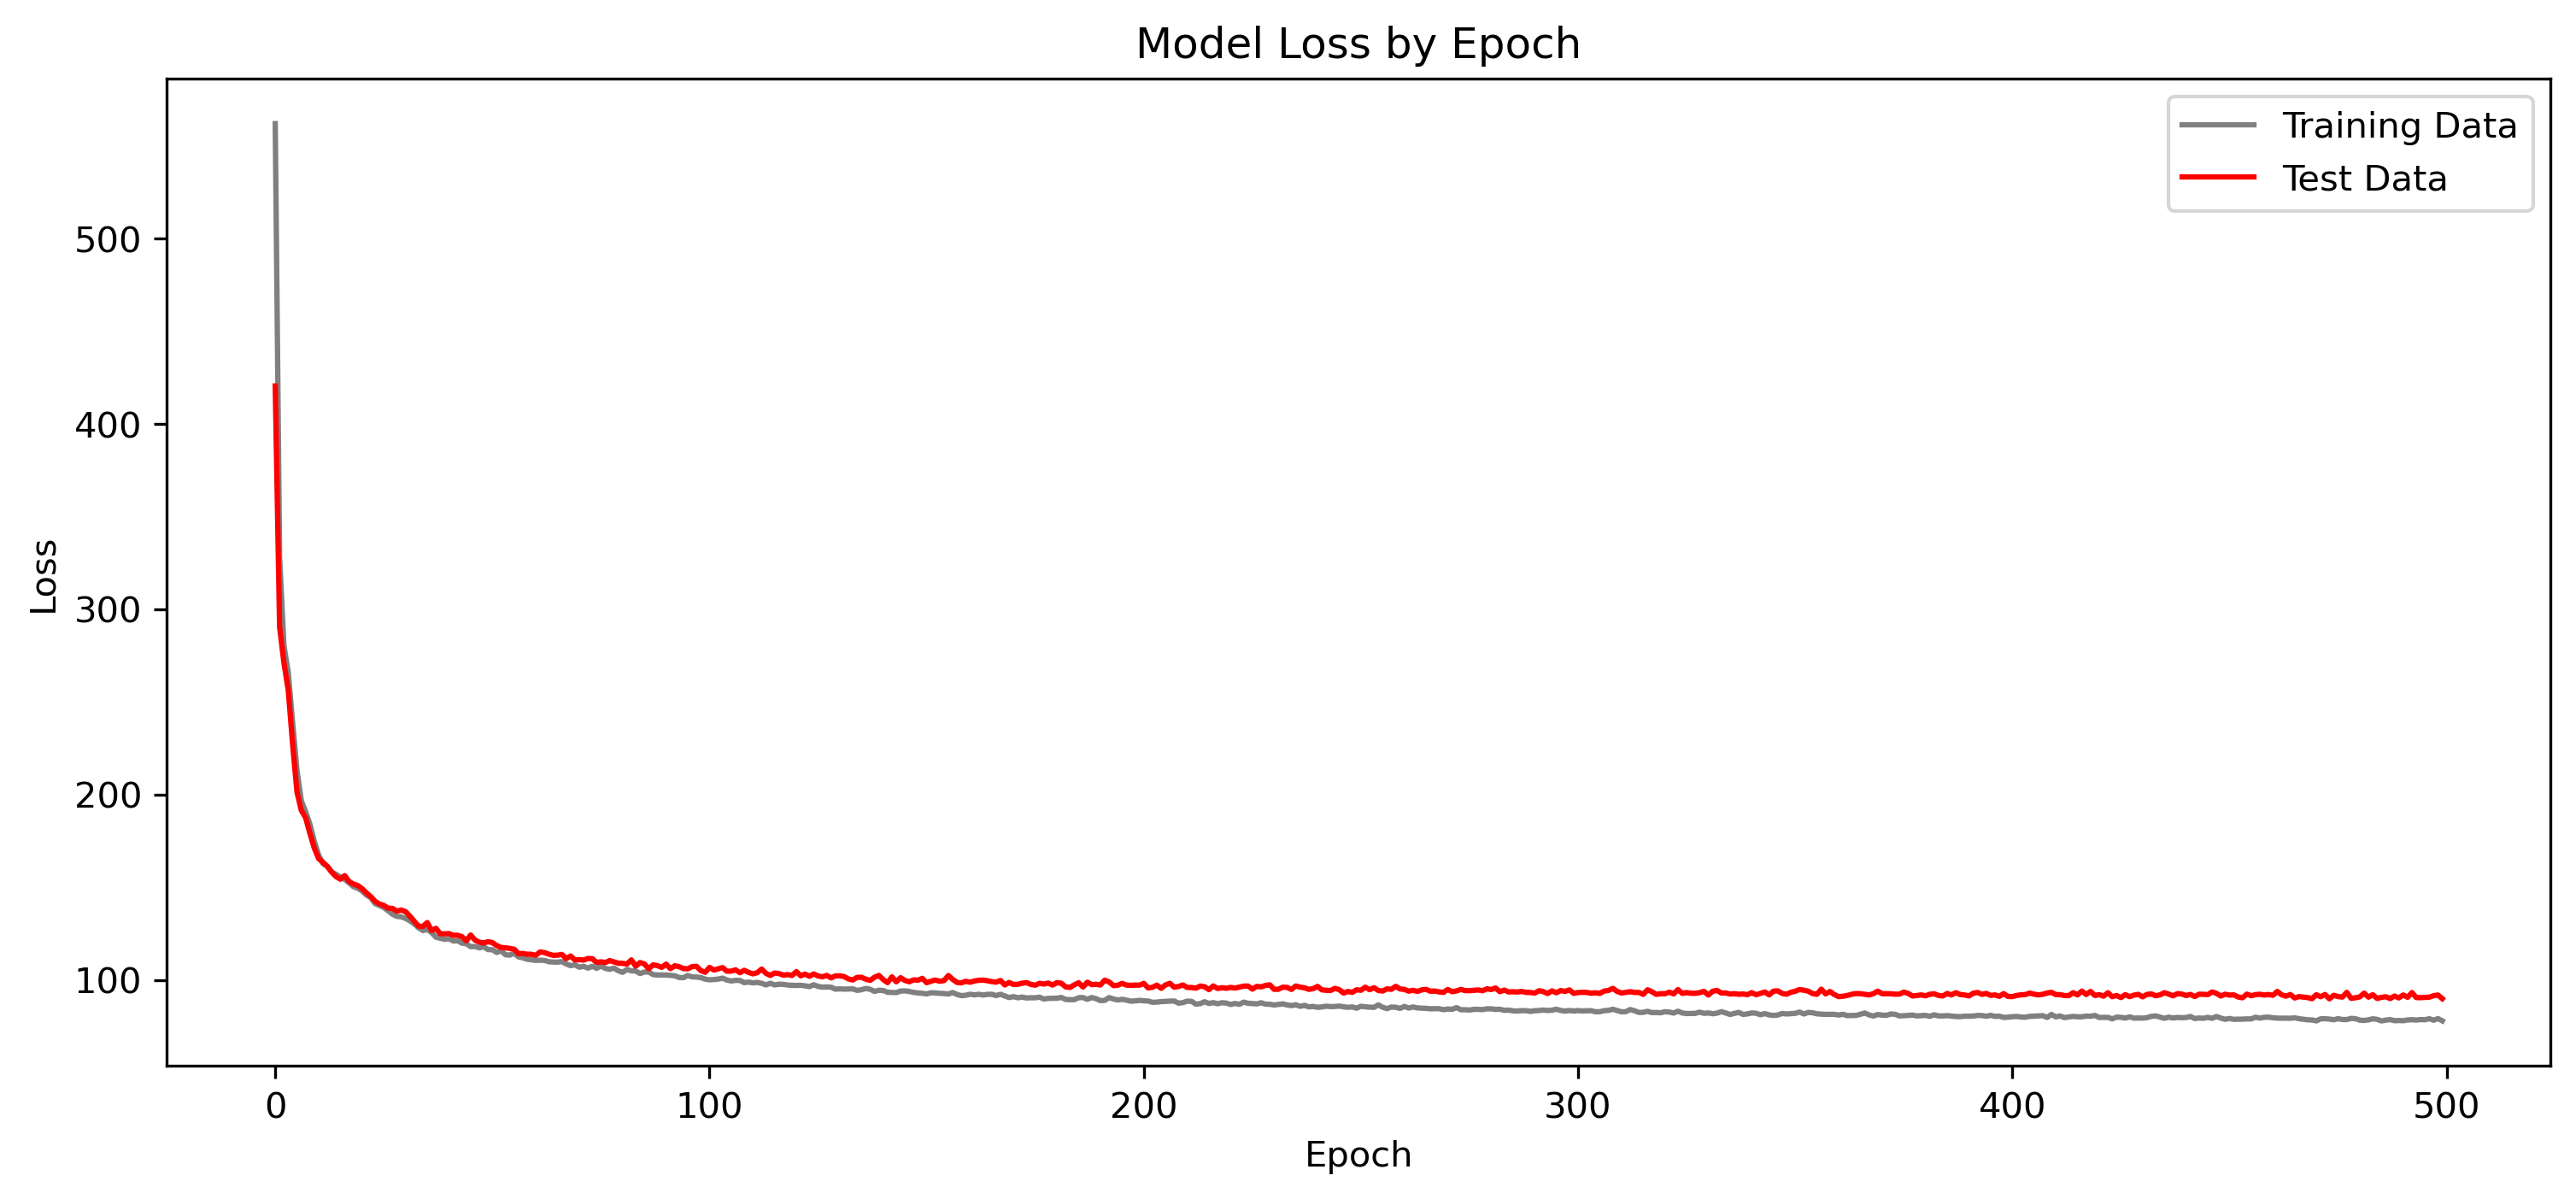

In [53]:
number = 0

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)